# GLOF (Glacial Lake Outburst Flood) Risk Prediction — India
### Data Cleaning → EDA → Model Training → Evaluation

**Dataset note:** No public labeled tabular GLOF dataset exists for India. This dataset combines 10 real, named Indian Himalayan lakes (real coordinates, elevation, area, and documented GLOF history/risk status from published research — South Lhonak, Chorabari, Parechu, Samudra Tapu, Gepang Gath, and the stable Sikkim lakes) with a literature-grounded synthetic expansion across India's glacier-bearing states/UTs (Jammu & Kashmir, Ladakh, Himachal Pradesh, Uttarakhand, Sikkim, Arunachal Pradesh), labeled using a transparent AHP-style multi-criteria risk score (not random labels). Synthetic lake coordinates are generated with rejection sampling against real state boundary polygons (not simple lat/lon rectangles), so every synthetic point genuinely falls inside Indian territory rather than spilling into Nepal, Bhutan, Tibet, or Myanmar at a state's corners. See `generate_dataset.py` for full methodology and sources.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("glof_dataset.csv")
df.head()

ModuleNotFoundError: No module named 'pandas'

## 1. Initial Inspection

In [ ]:
print("Shape:", df.shape)
df.info()

Shape: (796, 16)
<class 'pandas.DataFrame'>
RangeIndex: 796 entries, 0 to 795
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lake_id                   796 non-null    str    
 1   lake_name                 796 non-null    str    
 2   region                    796 non-null    str    
 3   latitude                  796 non-null    float64
 4   longitude                 796 non-null    float64
 5   elevation_m               796 non-null    float64
 6   lake_area_km2             796 non-null    float64
 7   glacier_retreat_m_per_yr  796 non-null    float64
 8   distance_from_glacier_m   796 non-null    float64
 9   slope_deg                 796 non-null    float64
 10  rainfall_mm               796 non-null    float64
 11  temperature_c             796 non-null    float64
 12  snowfall_mm               771 non-null    float64
 13  earthquake_magnitude      781 non-null    float64
 14  glof

In [ ]:
df.describe()

,latitude,longitude,elevation_m,lake_area_km2,glacier_retreat_m_per_yr,distance_from_glacier_m,slope_deg,rainfall_mm,temperature_c,snowfall_mm,earthquake_magnitude,glof_risk
count,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,771.000000,781.000000,796.00000
mean,31.724542,79.431246,4742.856658,0.449423,14.773153,641.682161,18.203015,2078.608166,-1.241721,1296.451492,3.982689,0.38191
std,2.136714,5.062916,729.480350,0.585972,10.829433,471.283627,8.654099,640.208718,3.549754,491.456818,0.783783,0.48616
min,27.106000,73.911900,1700.000000,0.010000,0.000000,50.000000,1.000000,300.000000,-10.000000,100.000000,2.000000,0.00000
25%,30.287400,76.732650,4102.200000,0.124000,6.080000,282.200000,12.200000,1641.625000,-3.685000,960.150000,3.450000,0.00000
50%,32.100850,77.914150,4752.600000,0.266000,14.320000,584.050000,17.900000,2076.300000,-1.350000,1280.000000,4.010000,0.00000
75%,33.446450,79.257400,5378.825000,0.514250,22.410000,943.300000,23.900000,2508.000000,1.242500,1627.650000,4.520000,1.00000
max,35.371900,97.013200,5998.500000,5.000000,53.500000,5000.000000,45.000000,3800.000000,12.590000,2800.000000,6.240000,1.00000


## 2. Data Cleaning
Remove duplicates, handle missing values, encode categoricals, and check data types — same checklist used in the team's Phase 2 plan.

In [ ]:
print("Duplicate rows before cleaning:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after cleaning:", df.duplicated().sum())

print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Duplicate rows before cleaning: 6
Duplicate rows after cleaning: 0

Missing values per column:
snowfall_mm             25
earthquake_magnitude    15
dtype: int64


In [ ]:
# Handle missing values: numeric columns -> median imputation (robust to outliers)
for col in ["snowfall_mm", "earthquake_magnitude"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


In [ ]:
# Encode categorical column (region)
df["region_encoded"] = df["region"].astype("category").cat.codes
region_map = dict(enumerate(df["region"].astype("category").cat.categories))
print("Region encoding:", region_map)

Region encoding: {0: 'Arunachal Pradesh', 1: 'Himachal Pradesh', 2: 'Jammu & Kashmir', 3: 'Ladakh', 4: 'Sikkim', 5: 'Uttarakhand'}


## 3. Exploratory Data Analysis (EDA)

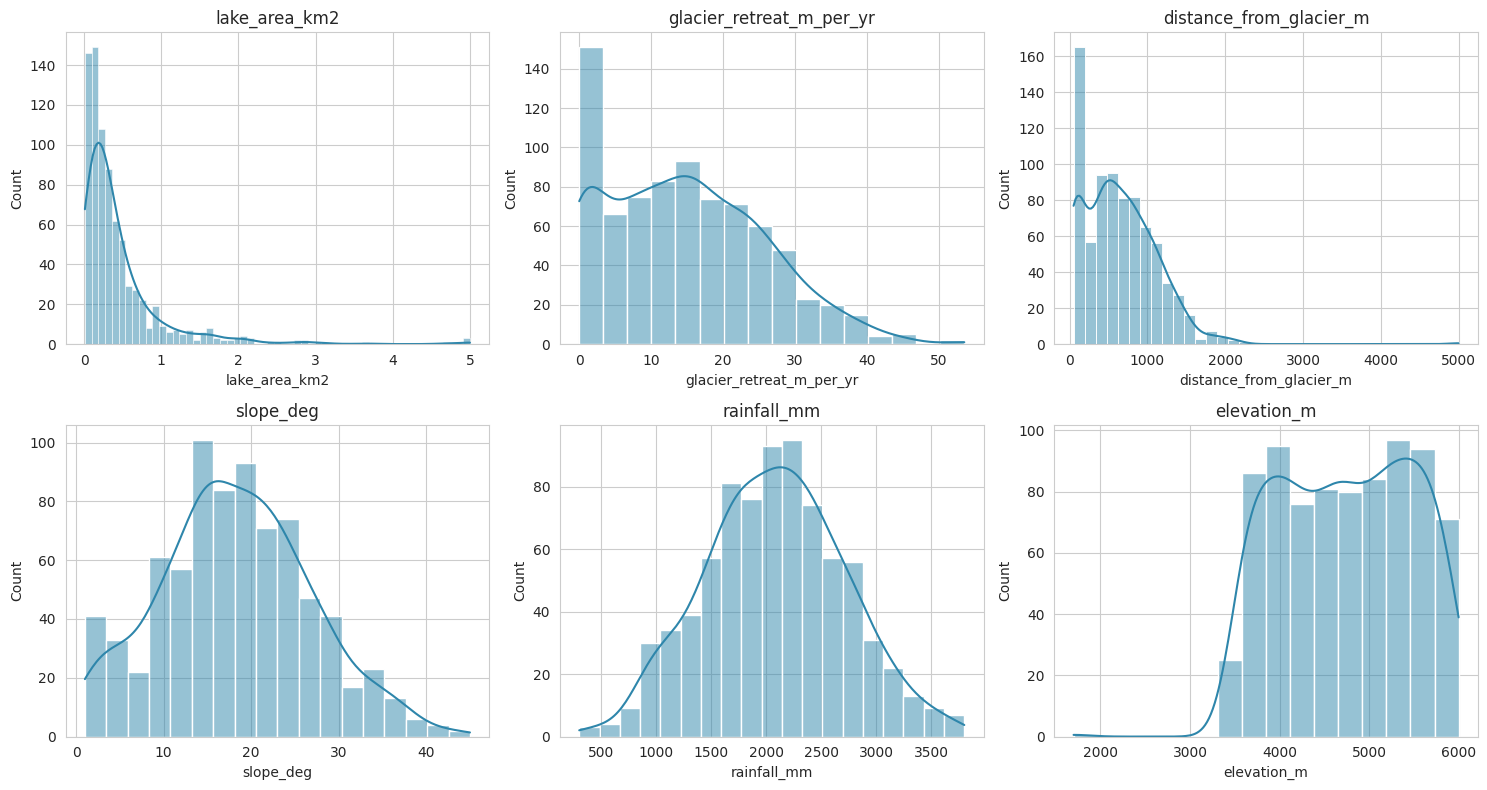

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ["lake_area_km2", "glacier_retreat_m_per_yr", "distance_from_glacier_m",
            "slope_deg", "rainfall_mm", "elevation_m"]
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#2E86AB")
    ax.set_title(col)
plt.tight_layout()
plt.show()

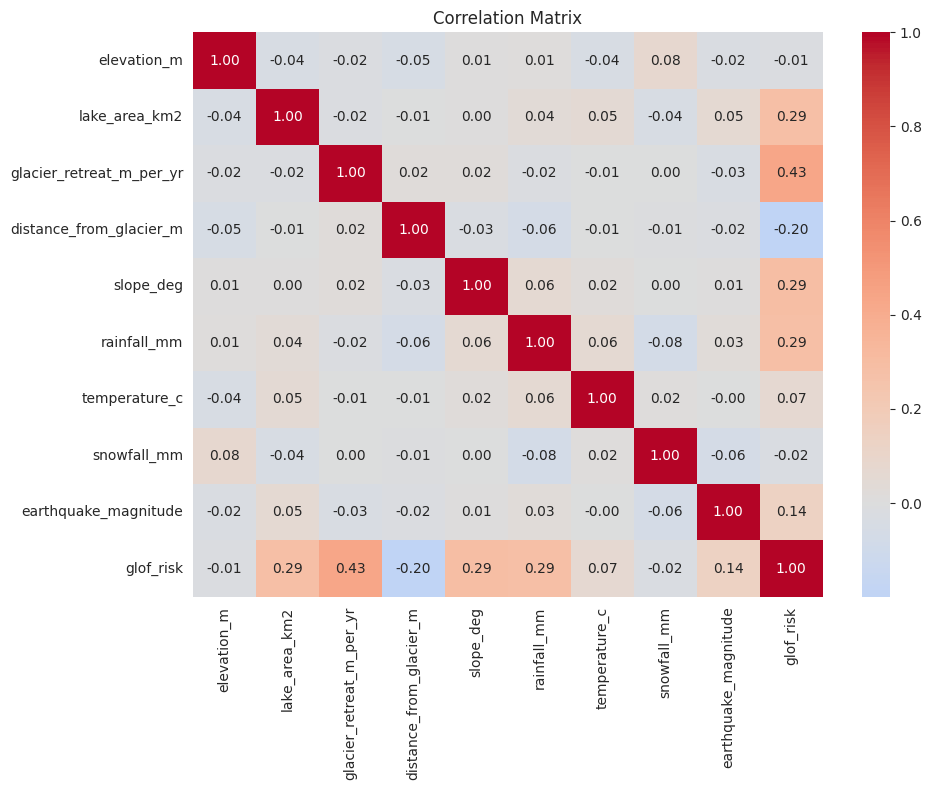

In [ ]:
plt.figure(figsize=(10, 8))
corr_cols = ["elevation_m", "lake_area_km2", "glacier_retreat_m_per_yr",
             "distance_from_glacier_m", "slope_deg", "rainfall_mm",
             "temperature_c", "snowfall_mm", "earthquake_magnitude", "glof_risk"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

/tmp/ipykernel_551/1480690279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="glof_risk", y=col, data=df, ax=ax, palette=["#4CAF6D", "#E84B4B"])
/tmp/ipykernel_551/1480690279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="glof_risk", y=col, data=df, ax=ax, palette=["#4CAF6D", "#E84B4B"])
/tmp/ipykernel_551/1480690279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="glof_risk", y=col, data=df, ax=ax, palette=["#4CAF6D", "#E84B4B"])


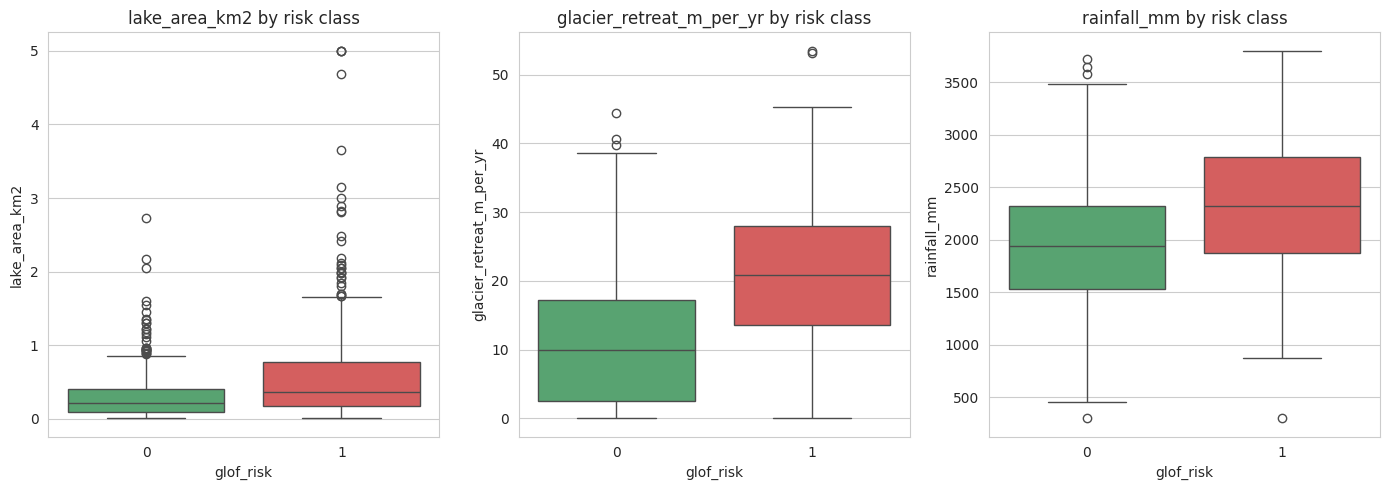

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ["lake_area_km2", "glacier_retreat_m_per_yr", "rainfall_mm"]):
    sns.boxplot(x="glof_risk", y=col, data=df, ax=ax, palette=["#4CAF6D", "#E84B4B"])
    ax.set_title(f"{col} by risk class")
plt.tight_layout()
plt.show()

In [ ]:
# Outlier detection using IQR method
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).sum()

for col in num_cols:
    print(f"{col}: {iqr_outliers(df[col])} outliers (IQR method)")

lake_area_km2: 69 outliers (IQR method)
glacier_retreat_m_per_yr: 2 outliers (IQR method)
distance_from_glacier_m: 8 outliers (IQR method)
slope_deg: 5 outliers (IQR method)
rainfall_mm: 2 outliers (IQR method)
elevation_m: 1 outliers (IQR method)


In [ ]:
print("Class balance (glof_risk):")
print(df["glof_risk"].value_counts())
print(df["glof_risk"].value_counts(normalize=True).round(3))

Class balance (glof_risk):
glof_risk
0    488
1    302
Name: count, dtype: int64
glof_risk
0    0.618
1    0.382
Name: proportion, dtype: float64


## 4. Feature Engineering

In [ ]:
df["risk_score_proxy"] = (
    df["lake_area_km2"].rank(pct=True) * 0.3 +
    df["glacier_retreat_m_per_yr"].rank(pct=True) * 0.25 +
    (1 - df["distance_from_glacier_m"].rank(pct=True)) * 0.2 +
    df["rainfall_mm"].rank(pct=True) * 0.15 +
    df["slope_deg"].rank(pct=True) * 0.1
)

feature_cols = ["elevation_m", "lake_area_km2", "glacier_retreat_m_per_yr",
                 "distance_from_glacier_m", "slope_deg", "rainfall_mm",
                 "temperature_c", "snowfall_mm", "earthquake_magnitude", "region_encoded"]

X = df[feature_cols]
y = df["glof_risk"]
print("Feature matrix:", X.shape, " Target:", y.shape)

Feature matrix: (790, 10)  Target: (790,)


## 5. Train / Validation / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (553, 10)  Val: (118, 10)  Test: (119, 10)


## 6. Train Models
Trying Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting (a scikit-learn equivalent to XGBoost — same gradient-boosted-tree family).

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42),
}

results = []
trained_models = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_s, y_train)
        preds = model.predict(X_val_s)
        proba = model.predict_proba(X_val_s)[:, 1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        proba = model.predict_proba(X_val)[:, 1]

    trained_models[name] = model
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, preds),
        "Precision": precision_score(y_val, preds),
        "Recall": recall_score(y_val, preds),
        "F1 Score": f1_score(y_val, preds),
        "ROC-AUC": roc_auc_score(y_val, proba),
    })

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.855932,0.833333,0.777778,0.804598,0.928767
1,Random Forest,0.830508,0.790698,0.755556,0.772727,0.895890
2,Gradient Boosting,0.796610,0.733333,0.733333,0.733333,0.882801
3,Decision Tree,0.728814,0.696970,0.511111,0.589744,0.724505


## 7. Compare Models

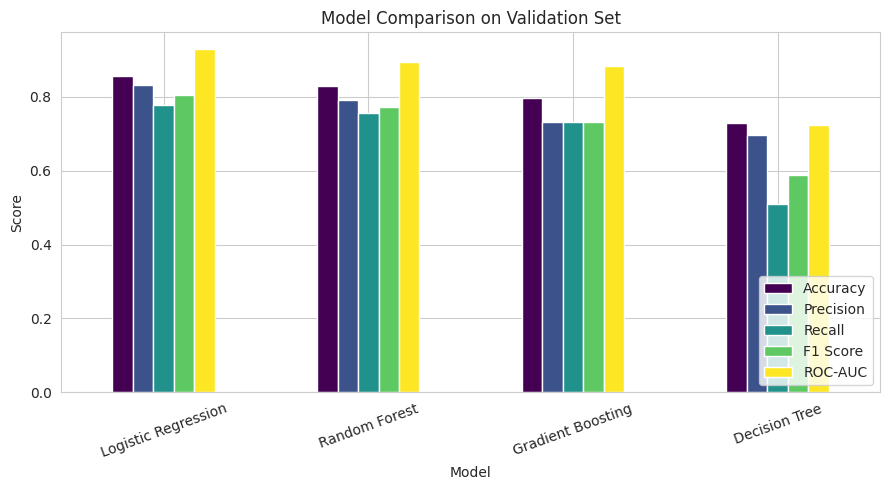

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(
    kind="bar", ax=ax, colormap="viridis"
)
plt.title("Model Comparison on Validation Set")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Final Evaluation on Held-Out Test Set

In [ ]:
best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]
print("Best model (by validation F1):", best_name)

if best_name == "Logistic Regression":
    X_test_input = scaler.transform(X_test)
else:
    X_test_input = X_test

test_preds = best_model.predict(X_test_input)
test_proba = best_model.predict_proba(X_test_input)[:, 1]

print("\n--- Test Set Performance ---")
print("Accuracy: ", round(accuracy_score(y_test, test_preds), 3))
print("Precision:", round(precision_score(y_test, test_preds), 3))
print("Recall:   ", round(recall_score(y_test, test_preds), 3))
print("F1 Score: ", round(f1_score(y_test, test_preds), 3))
print("ROC-AUC:  ", round(roc_auc_score(y_test, test_proba), 3))

Best model (by validation F1): Logistic Regression

--- Test Set Performance ---
Accuracy:  0.882
Precision: 0.881
Recall:    0.804
F1 Score:  0.841
ROC-AUC:   0.961


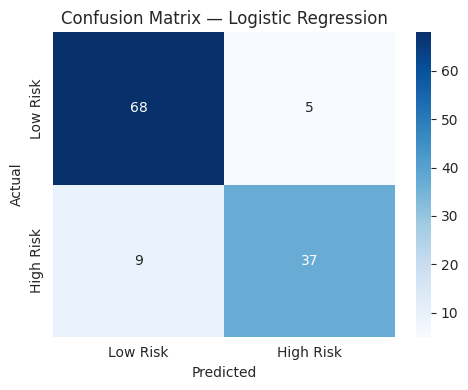

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low Risk", "High Risk"], yticklabels=["Low Risk", "High Risk"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

## 9. Feature Importance (Explainability)
Feature importance from the best tree-based model — a lightweight, always-available explainability view. The Streamlit dashboard adds full SHAP explanations (per-prediction reasoning) using the `shap` library.

/tmp/ipykernel_551/1228452094.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs.values, y=coefs.index, palette="mako")


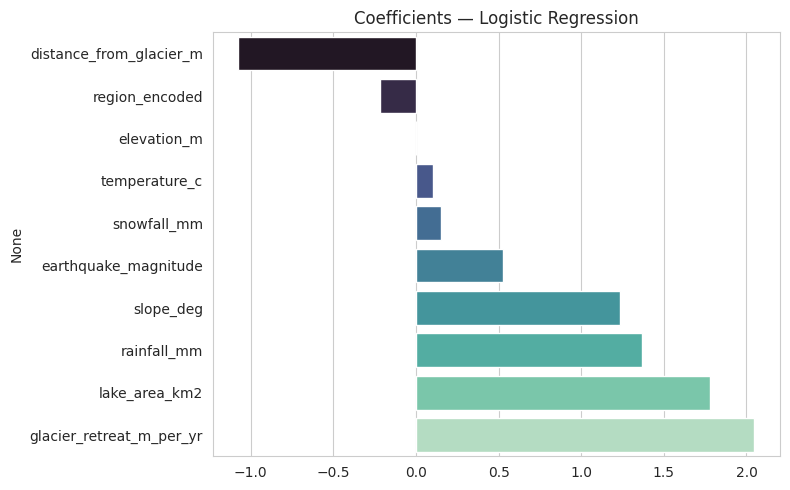

In [ ]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, palette="mako")
    plt.title(f"Feature Importance — {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    coefs = pd.Series(best_model.coef_[0], index=feature_cols).sort_values()
    plt.figure(figsize=(8, 5))
    sns.barplot(x=coefs.values, y=coefs.index, palette="mako")
    plt.title(f"Coefficients — {best_name}")
    plt.tight_layout()
    plt.show()

## 10. Save Best Model
Saved as `.joblib` so the Streamlit dashboard (Phase 7) can load it directly for live predictions.

Saved model: Logistic Regression
Files written: glof_model.joblib, glof_scaler.joblib, glof_feature_cols.joblib, glof_region_map.joblib


## 11. Deliverables Summary

- ✅ Clean dataset (`glof_dataset.csv`)
- ✅ EDA notebook (this file)
- ✅ Trained model + evaluation report (above)
- ✅ Saved model artifacts for the dashboard

Next: Phase 4–8 (GIS map, satellite comparison, SHAP, dashboard, alerts) are implemented in `app.py` (Streamlit dashboard).